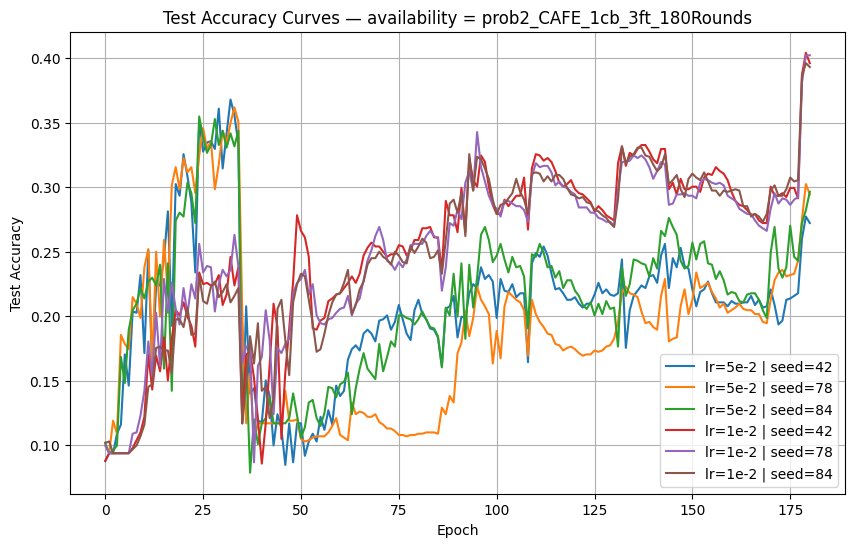

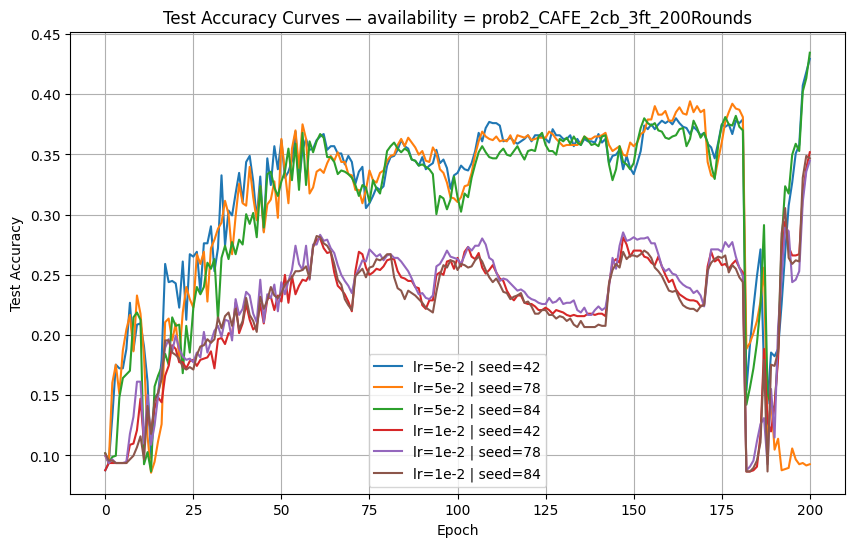

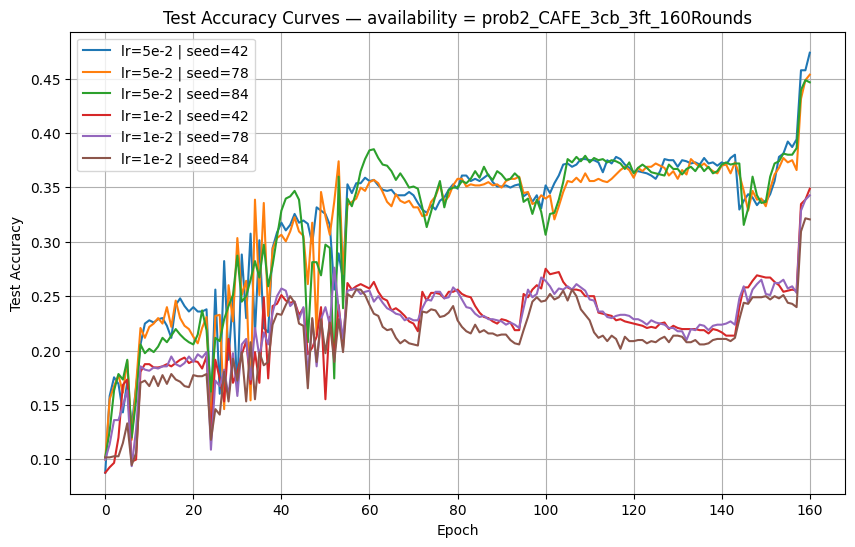

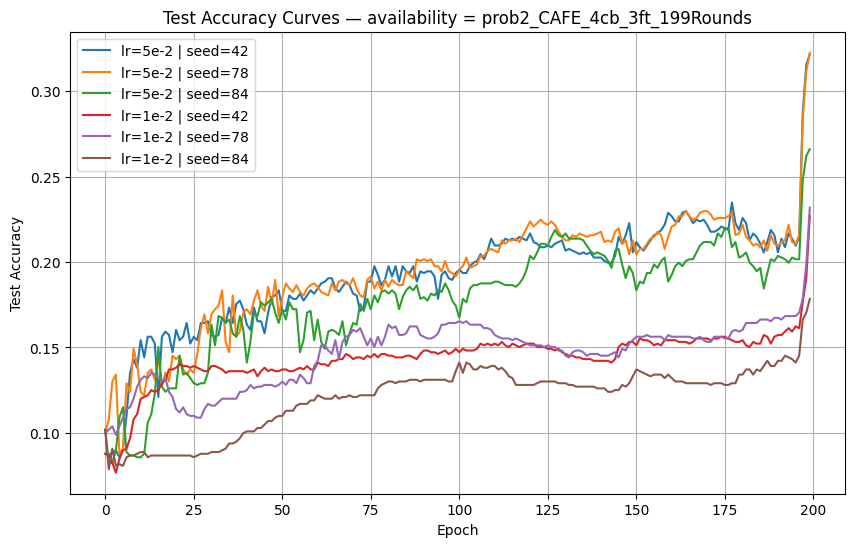

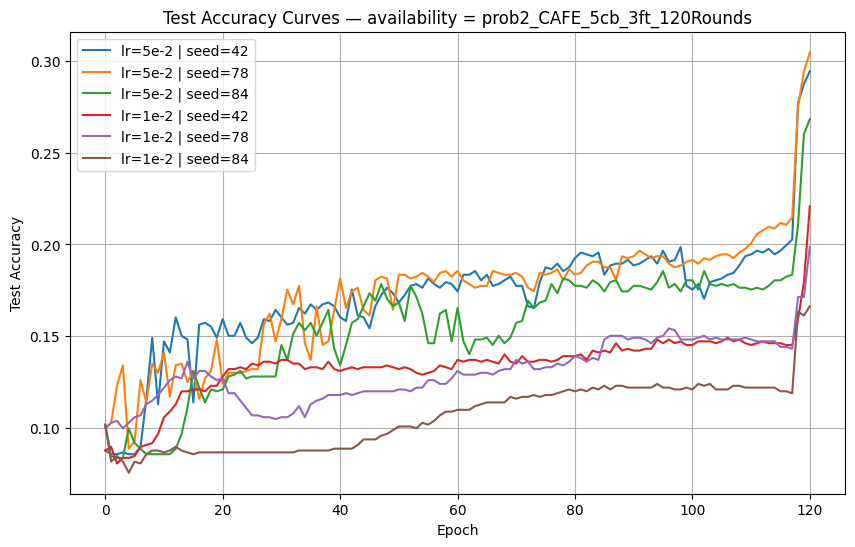

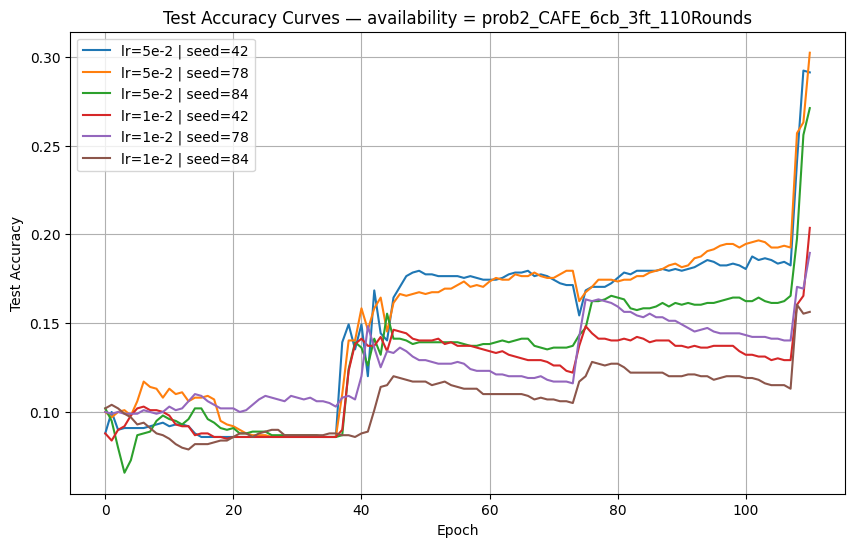

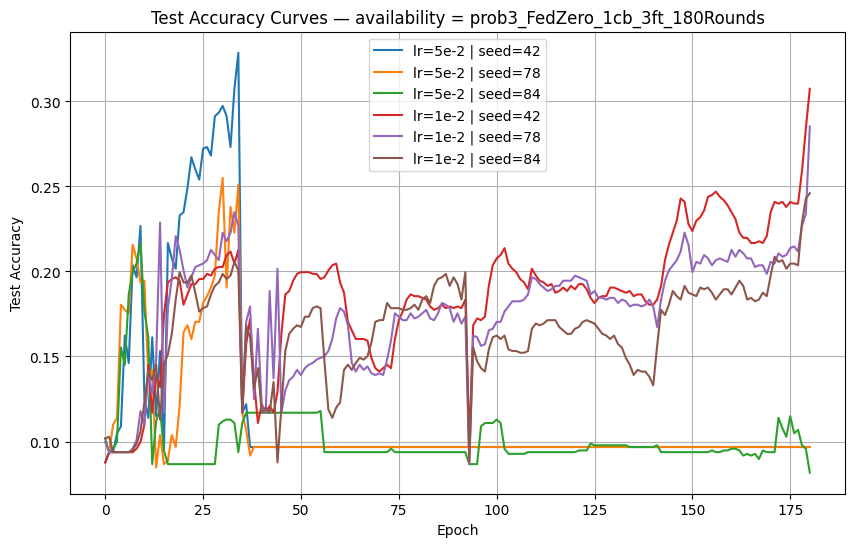

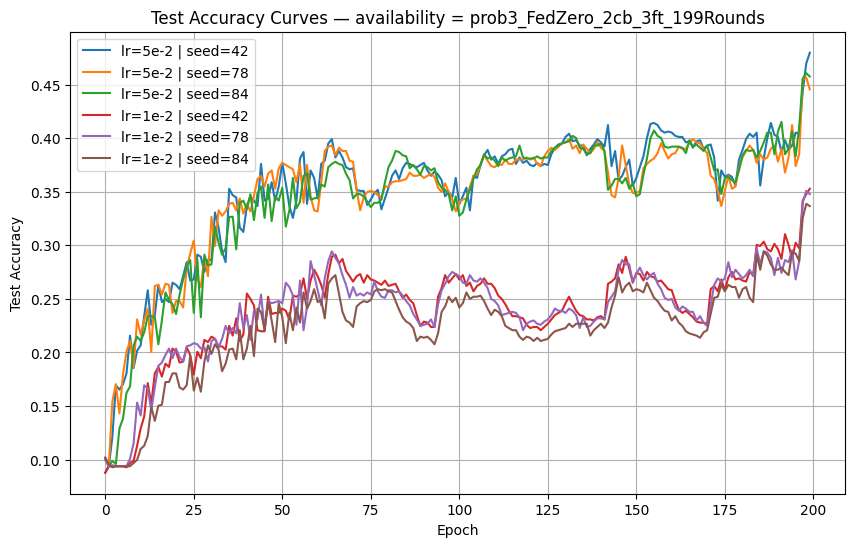

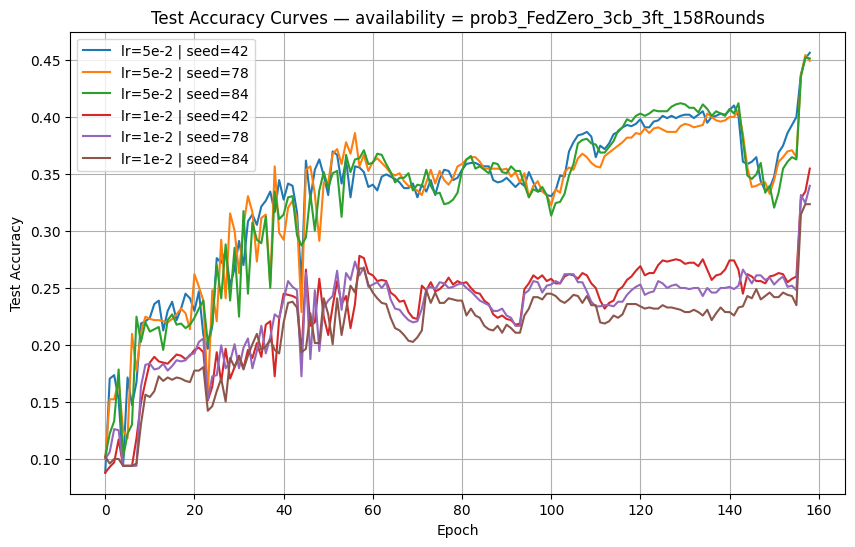

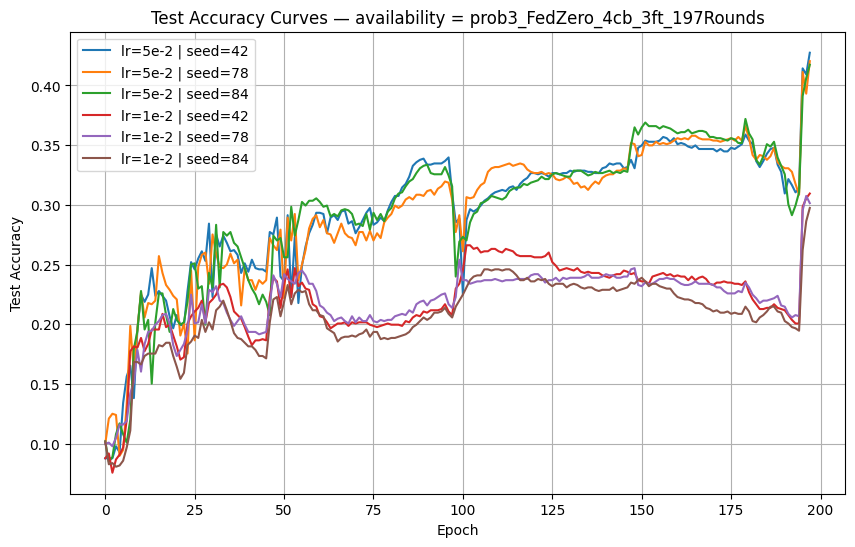

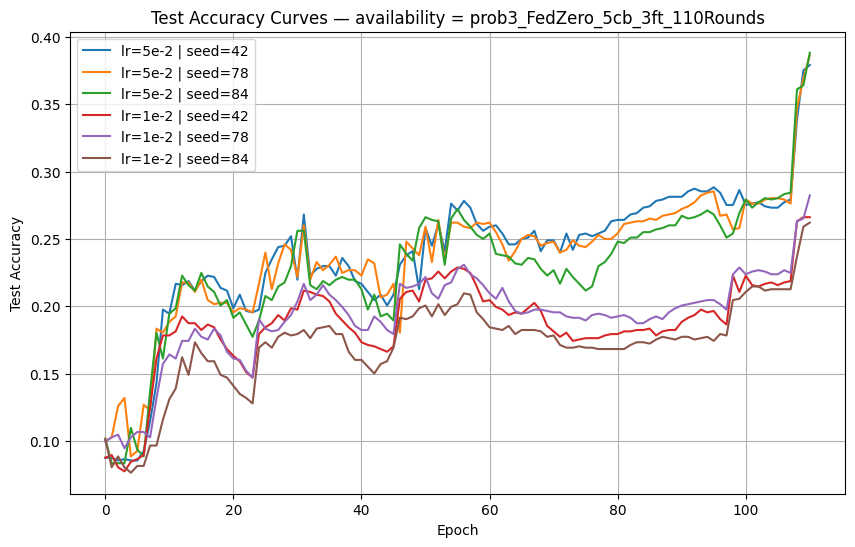

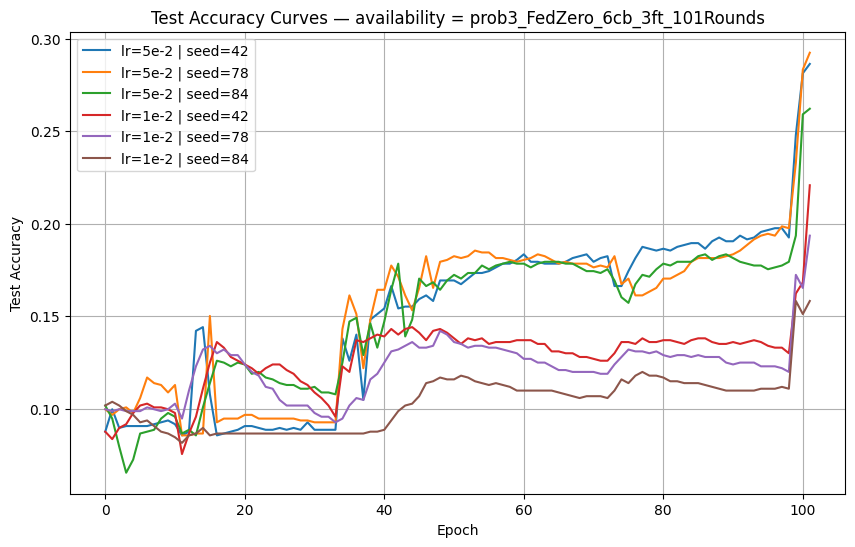

In [4]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        # print(event_dir)
                                        # print(event_dir.split('/'))
                                        # print(os.path.exists(event_dir))

                                        if os.path.exists(event_dir):
                                            # print('helloooo')
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            # _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            # _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            # _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

main_folder = 'baselines_accuracy_check'

availabilities="""
prob2_CAFE_1cb_3ft_180Rounds 
prob2_CAFE_2cb_3ft_200Rounds 
prob2_CAFE_3cb_3ft_160Rounds 
prob2_CAFE_4cb_3ft_199Rounds 
prob2_CAFE_5cb_3ft_120Rounds 
prob2_CAFE_6cb_3ft_110Rounds 
prob3_FedZero_1cb_3ft_180Rounds 
prob3_FedZero_2cb_3ft_199Rounds 
prob3_FedZero_3cb_3ft_158Rounds 
prob3_FedZero_4cb_3ft_197Rounds 
prob3_FedZero_5cb_3ft_110Rounds 
prob3_FedZero_6cb_3ft_101Rounds 
""".split()
exp_folder="cifar_baselines_with_ft_group_notclip_bestEndFT"

config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment=exp_folder, seeds=["42", "78", "84"],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['5e-2', '1e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="200", participations=["known"], biased_list=["2"], train_test="train")

results_df = get_exp_stats(config)

results_df

# display(results_df)

import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
for availability_value, group in results_df.groupby("availability"):
    
    plt.figure(figsize=(10, 6))
    
    for _, row in group.iterrows():
        label = f"lr={row['lr']} | seed={row['seed']}"
        plt.plot(row['test_accuracy'], label=label)
    
    plt.title(f"Test Accuracy Curves — availability = {availability_value}")
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

### To check the gradient

In [5]:
# _, test_acc_global = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global", tag="Test/Metric")
# _, test_global_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global", tag="Test/GradNorm")
# _, test_acc_1 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_0", tag="Test/Metric")
# _, test_1_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_0", tag="Test/GradNorm")
# _, test_acc_2 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_1", tag="Test/Metric")
# _, test_2_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_1", tag="Test/GradNorm")
# _, test_acc_3 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_2", tag="Test/Metric")
# _, test_3_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_2", tag="Test/GradNorm")
# _, test_acc_4 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_3", tag="Test/Metric")
# _, test_4_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_3", tag="Test/GradNorm")
# _, test_acc_5 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_4", tag="Test/Metric")
# _, test_5_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_4", tag="Test/GradNorm")
# _, test_acc_6 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_5", tag="Test/Metric")
# _, test_6_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_5", tag="Test/GradNorm")
# _, test_acc_7 = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_6", tag="Test/Metric")
# _, test_7_grad = parse_tf_events_file(f"../logs/cifar_baselines_with_ft_group_notclip/prob1_alphaFair_3cb_3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/task_6", tag="Test/GradNorm")

# # Create a figure with 8 subplots (one for each task, including the global one)
# fig, axs = plt.subplots(8, 1, figsize=(10, 25), sharex=True)

# # Define the data and labels for each subplot
# tasks = [
#     ("Global", test_acc_global, test_global_grad),
#     ("Task 0", test_acc_1, test_1_grad),
#     ("Task 1", test_acc_2, test_2_grad),
#     ("Task 2", test_acc_3, test_3_grad),
#     ("Task 3", test_acc_4, test_4_grad),
#     ("Task 4", test_acc_5, test_5_grad),
#     ("Task 5", test_acc_6, test_6_grad),
#     ("Task 6", test_acc_7, test_7_grad),
# ]
# print("Final Accuracy:", test_acc_global[-1])
# x_values = np.arange(201)  # This will create an array from 0 to 100 (101 data points)
# x_ticks = np.arange(0, 201, 10)  # This will create ticks every 5 epochs (0, 5, 10, ..., 100)
# # Loop through each subplot and plot the data
# for i, (task_name, acc_data, grad_data) in enumerate(tasks):
#     ax1 = axs[i]  # Select the subplot

#     # Plot accuracy on the left y-axis
#     ax1.plot(acc_data, 'r', label=f'Accuracy ({task_name})', linewidth=2)
#     ax1.set_ylabel('Accuracy', color='r')
#     ax1.tick_params(axis='y', labelcolor='r')

#     # Create the second y-axis for gradient norm
#     ax2 = ax1.twinx()
#     ax2.plot(grad_data, 'g', label=f'Grad Norm ({task_name})', linestyle='--', linewidth=2)
#     ax2.set_ylabel('Gradient Norm', color='g')
#     ax2.tick_params(axis='y', labelcolor='g')

#     # Set title for each subplot
#     ax1.set_title(f"{task_name} - Accuracy and Gradient Norm")

#     # Set the x-ticks and labels on every subplot
#     ax2.set_xticks(x_ticks)
#     ax2.set_xticklabels(x_ticks)

#     # Optional: Add legend to each subplot
#     ax1.legend(loc='upper left')
#     ax2.legend(loc='upper right')

# # Set x-axis label for the bottom subplot
# axs[-1].set_xlabel('Epochs')

# # Adjust layout to prevent overlap
# fig.tight_layout()

# # Show the plot
# plt.show()